# VAE on 2D Circles -- Milestone 1

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_circles

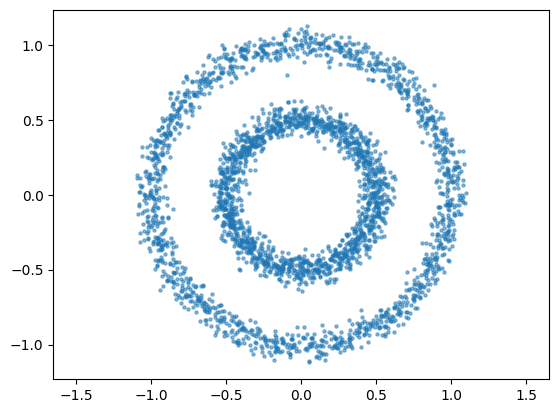

In [2]:
def get_data(batch_size=256):
    X, _ = make_circles(n_samples=3000, noise=0.05, factor=0.5)
    X = torch.FloatTensor(X)
    return DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True), X

train_loader, full_data = get_data()
plt.scatter(full_data[:, 0], full_data[:, 1], s=5, alpha=0.5)
plt.axis('equal')
plt.show()

### Model

In [3]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim * 2)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        mu, logvar = self.encoder(x).chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Loss (ELBO)

In [4]:
def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

### Training

In [5]:
def train_vae(model, loader, epochs=200, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0
        for batch in loader:
            x = batch[0]
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        history['loss'].append(total_loss)
        history['recon'].append(total_recon)
        history['kl'].append(total_kl)

        if epoch % 20 == 0:
            print(f"epoch {epoch:3d} | loss {total_loss:.2f} | recon {total_recon:.2f} | kl {total_kl:.2f}")

    return history

model = LinearVAE()
history = train_vae(model, train_loader)

epoch   0 | loss 3419.02 | recon 3373.17 | kl 458.55


epoch  20 | loss 1873.29 | recon 1795.59 | kl 777.01


epoch  40 | loss 1481.93 | recon 1343.74 | kl 1381.82


epoch  60 | loss 1244.47 | recon 1040.48 | kl 2039.86


epoch  80 | loss 1172.35 | recon 905.00 | kl 2673.50


epoch 100 | loss 1033.21 | recon 705.09 | kl 3281.21


epoch 120 | loss 978.61 | recon 596.39 | kl 3822.23


epoch 140 | loss 929.68 | recon 503.83 | kl 4258.48


epoch 160 | loss 919.76 | recon 461.92 | kl 4578.38


epoch 180 | loss 898.68 | recon 419.46 | kl 4792.27


### Checkpoint 1 -- loss curve

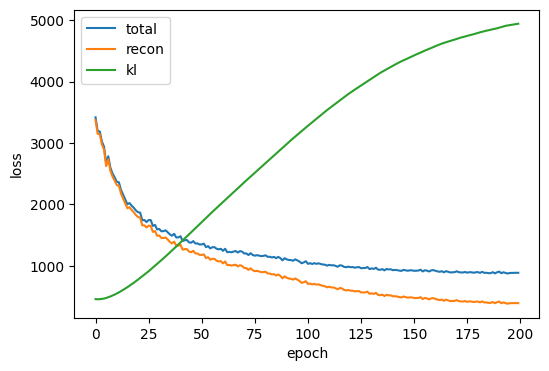

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(history['loss'], label='total')
plt.plot(history['recon'], label='recon')
plt.plot(history['kl'], label='kl')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### Checkpoint 2 -- reconstructions

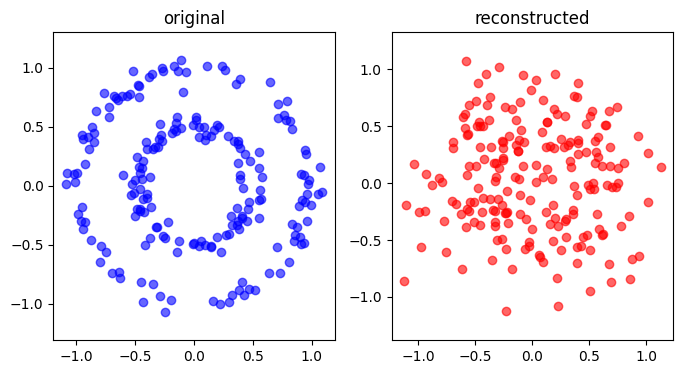

In [7]:
def plot_reconstructions(model, data, n=200):
    with torch.no_grad():
        recon, _, _ = model(data[:n])

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(data[:n, 0], data[:n, 1], c='blue', alpha=0.6)
    plt.title('original')
    plt.axis('equal')
    plt.subplot(1, 2, 2)
    plt.scatter(recon[:, 0], recon[:, 1], c='red', alpha=0.6)
    plt.title('reconstructed')
    plt.axis('equal')
    plt.show()

plot_reconstructions(model, full_data)

### Checkpoint 3 -- latent space

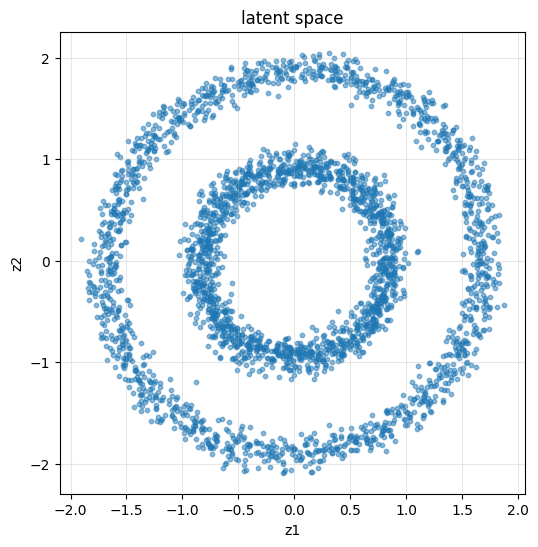

In [8]:
def plot_latent_space(model, data):
    with torch.no_grad():
        mu, _ = model.encode(data)

    plt.figure(figsize=(6, 6))
    plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5, s=10)
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.title('latent space')
    plt.grid(alpha=0.3)
    plt.show()

plot_latent_space(model, full_data)

### Checkpoint 4 -- generated samples

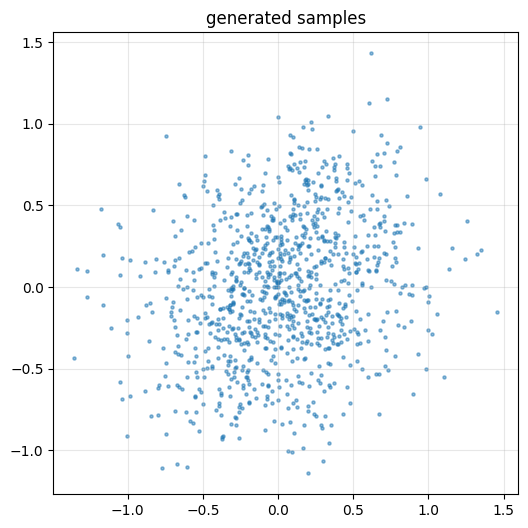

In [9]:
def plot_generated(model, n=1000):
    with torch.no_grad():
        z = torch.randn(n, 2)
        samples = model.decode(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5)
    plt.title('generated samples')
    plt.grid(alpha=0.3)
    plt.show()

plot_generated(model)

`beta=0.1` keeps the KL term from dominating -- at `beta=1` the posterior collapses (mu->0, sigma->1) and reconstructions all shrink to a blob near the origin. Because the decoder is a single linear layer, decoding Gaussian noise can only ever produce an elliptical blob, not an actual ring -- that needs nonlinearity (Week 4).